# 1. Data Preparation
This [dataset](https://www.kaggle.com/datasets/rabieelkharoua/air-quality-and-health-impact-dataset) contains comprehensive information on the air quality and its impact on public health for 5,811 records. It includes variables such as air quality index (AQI), concentrations of various pollutants, weather conditions, and health impact metrics. The target variable is the health impact class, which categorizes the health impact based on the air quality and other related factors.

This dataset offers a comprehensive view of the relationship between air quality and public health, making it ideal for research, predictive modeling, and statistical analysis.

In [1]:
include("utils.jl")

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
┌ Info: Running `conda install -y -c anaconda conda` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - anaconda
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - conda


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            conda-forge/noarch::certifi-2024.8.30~ --> anaconda/linux-64::certifi-2024.8.30-py312h06a4308_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


┌ Info: Running `conda install -y -c conda-forge 'libstdcxx-ng>=3.4,<13.0'` in root environment
└ @ Conda /home/pablo/.julia/packages/Conda/zReqD/src/Conda.jl:181


Channels:
 - conda-forge
 - bioconda
 - defaults
 - anaconda
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /home/pablo/.julia/conda/3/x86_64

  added / updated specs:
    - libstdcxx-ng[version='>=3.4,<13.0']


The following packages will be SUPERSEDED by a higher-priority channel:

  certifi            anaconda/linux-64::certifi-2024.8.30-~ --> conda-forge/noarch::certifi-2024.8.30-pyhd8ed1ab_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


averageAccuracies (generic function with 1 method)

In [2]:
using CSV, DataFrames

# Load the dataset from the 'dataset' folder
data = CSV.read("datasets/air_quality_health_impact_data.csv", DataFrame)

# Check the dataset
describe(data)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,RecordID,2906.0,1,2906.0,5811,0,Int64
2,AQI,248.438,0.00581738,249.128,499.859,0,Float64
3,PM10,148.655,0.0158481,147.635,299.902,0,Float64
4,PM2_5,100.224,0.0315489,100.506,199.985,0,Float64
5,NO2,102.293,0.00962478,102.988,199.98,0,Float64
6,SO2,49.4568,0.0110232,49.5302,99.9696,0,Float64
7,O3,149.312,0.001661,149.56,299.937,0,Float64
8,Temperature,14.9755,-9.991,14.9424,39.9634,0,Float64
9,Humidity,54.7769,10.0015,54.5439,99.9975,0,Float64


In [3]:
# Count elements in each class
counts = combine(groupby(data, :HealthImpactClass), nrow => :Count)

println("Elements per class:")
println(counts)

Elements per class:
5×2 DataFrame
 Row │ HealthImpactClass  Count 
     │ Float64            Int64 
─────┼──────────────────────────
   1 │               0.0   4808
   2 │               1.0    579
   3 │               2.0    273
   4 │               3.0     95
   5 │               4.0     56


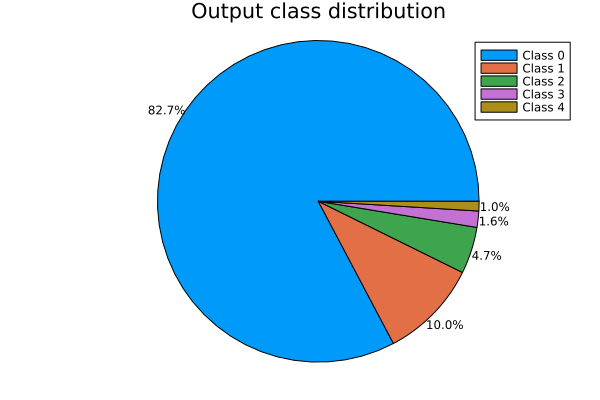

In [4]:
using Plots, Printf

cnt = counts.Count
labels = ["Class $i" for i in 0:4]
tot = sum(cnt)
datapct = [@sprintf("%.1f%%", x/tot*100) for x in cnt]

θ = (cumsum(cnt) - cnt/2) .* 360/sum(cnt)
scθ = sincosd.(θ)

p = pie(labels, cnt, title="Output class distribution")
for (s, sci) in zip(datapct, scθ)
    annotate!(1.1*sci[2], 1.1*sci[1], text(s, 8, :black))
end
p

In [5]:
input_data = Matrix(data[!, 1:13]);
output_data = Int.(data[!, 15]);

@assert input_data isa Matrix
@assert output_data isa Vector{Int64}

To split the test from train we use the holdOut function with a fraction of 0.2. This means that 20% of the train data will be used for testing and the remaining 80% will be used for training.

In [6]:
# Split in train and test
(tr_idx, test_idx) = holdOutStratified(output_data, 0.2)

train_input = input_data[tr_idx,:]
train_output = output_data[tr_idx]
test_input = input_data[test_idx,:]
test_output = output_data[test_idx]

train_output = collect(train_output)
test_output = collect(test_output)

println("Train Input Size: ", size(train_input))
println("Train Output Size: ", size(train_output), " Categories:", sort(unique(train_output)))
println("Test Input Size: ", size(test_input))
println("Test Output Size: ", size(test_output), " Categories:", sort(unique(test_output)))

Train Input Size: (4648, 13)
Train Output Size: (4648,) Categories:[0, 1, 2, 3, 4]
Test Input Size: (1163, 13)
Test Output Size: (1163,) Categories:[0, 1, 2, 3, 4]


In [7]:
columna = train_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 3846, 4 => 45, 2 => 218, 3 => 76, 1 => 463)


In [8]:
columna = test_output[:, 1]

conteo = Dict(c => count(==(c), columna) for c in 0:4)

println("Elements per class:")
println(conteo)

Elements per class:
Dict(0 => 962, 4 => 11, 2 => 55, 3 => 19, 1 => 116)


We will store the results in a DataFrame for easy ploting

In [105]:
metric_names = [:approach, :accuracy, :error_rate, :recall, :specificity, :ppv, :npv, :f_score]
metric_types = [String[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[], Float64[]]
metrics = DataFrame(metric_types, metric_names)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64


# 2. Definition of Models and Hyperparameters

In [99]:
## These are the modelsHyperParameters to be used in the models training

modelsHyperParameters = [
    # ANN configurations
    Dict("estimator" => :ANN, "topology" => (64,), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_64"),
    Dict("estimator" => :ANN, "topology" => (128,), "maxEpochs" => 500, "learningRate" => 0.005, "name" => "ANN_128"),
    Dict("estimator" => :ANN, "topology" => (64, 32), "maxEpochs" => 400, "learningRate" => 0.001, "name" => "ANN_64_32"),
    Dict("estimator" => :ANN, "topology" => (128, 64), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64"),
    Dict("estimator" => :ANN, "topology" => (256,), "maxEpochs" => 300, "learningRate" => 0.05, "name" => "ANN_256"),
    Dict("estimator" => :ANN, "topology" => (128, 64, 32), "maxEpochs" => 200, "learningRate" => 0.01, "name" => "ANN_128_64_32"),
    Dict("estimator" => :ANN, "topology" => (64, 64), "maxEpochs" => 250, "learningRate" => 0.005, "name" => "ANN_64_64"),
    Dict("estimator" => :ANN, "topology" => (256, 128), "maxEpochs" => 200, "learningRate" => 0.001, "name" => "ANN_256_128"),

    # SVM configurations
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.5, "degree"=>2, "name" => "SVM_rbf_05"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C" => 1.0, "degree"=>4, "name" => "SVM_linear_1"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 0.01 , "degree" => 2, "name" => "SVM_poly_001"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 1.0, "degree" => 3, "name" => "SVM_sigmoid_1"),
    Dict("estimator" => :SVM, "kernel" => "rbf", "C" => 0.01, "degree" => 3, "name" => "SVM_rbf_001"),
    Dict("estimator" => :SVM, "kernel" => "poly", "C"=> 5, "degree" => 3, "name" => "SVM_poly_5"),
    Dict("estimator" => :SVM, "kernel" => "linear", "C"=> 0.5, "degree" => 3, "name" => "SVM_linear_05"),
    Dict("estimator" => :SVM, "kernel" => "sigmoid", "C" => 10.0, "degree" => 5, "name" => "SVM_sigmoid_10"),

    # Decision Tree configurations
    Dict("estimator" => :DecisionTree, "max_depth" => 3, "random_state" => 42, "name" => "DT_3"),
    Dict("estimator" => :DecisionTree, "max_depth" => 5, "random_state" => 42, "name" => "DT_5"),
    Dict("estimator" => :DecisionTree, "max_depth" => 7, "random_state" => 42, "name" => "DT_7"),
    Dict("estimator" => :DecisionTree, "max_depth" => 11, "random_state" => 42, "name" => "DT_11"),
    Dict("estimator" => :DecisionTree, "max_depth" => 15, "random_state" => 42, "name" => "DT_15"),
    Dict("estimator" => :DecisionTree, "max_depth" => 21, "random_state" => 42, "name" => "DT_21"),

    # kNN configurations
    Dict("estimator" => :KNN, "k" => 3, "name" => "KNN_3"),
    Dict("estimator" => :KNN, "k" => 5, "name" => "KNN_5"),
    Dict("estimator" => :KNN, "k" => 7, "name" => "KNN_7"),
    Dict("estimator" => :KNN, "k" => 9, "name" => "KNN_9"),
    Dict("estimator" => :KNN, "k" => 11, "name" => "KNN_11"),
    Dict("estimator" => :KNN, "k" => 15, "name" => "KNN_15")
]

models_accuracies = DataFrame(Model = String[], MinMax = Float64[])
for m in modelsHyperParameters
    push!(models_accuracies, (m["name"], 0))
end


----
----

# 3. First approach: Using Min-Max Normalization.

In this approach we will use the Min-Max Normalization technique to normalize the data. And then, realize all the models training to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [106]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.8912220309810671 0.5385097684683934 … 0.0 0.75; 0.36265060240963853 0.9063980661176285 … 0.21428571428571427 0.5; … ; 0.387263339070568 0.09387324518506657 … 0.6428571428571429 0.25; 0.5232358003442341 0.17940578564518195 … 0.42857142857142855 0.125], [0.38141135972461276 0.8296269084484057 … 0.5 0.25; 0.20567986230636834 0.8717814415504206 … 0.6428571428571429 0.25; … ; 0.1144578313253012 0.1528924489178848 … 0.42857142857142855 0.25; 0.9070567986230637 0.19272141440146479 … 0.21428571428571427 0.25])

In this approach we wont use crossValidation, so we will train the models on the whole dataset and then evaluate them on the test set.

Pre-normalization data characteristics:

In [107]:
describe(DataFrame(train_input, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,2903.3,1.0,2898.0,5811.0,0,Float64
2,AQI,247.797,0.00581738,246.421,499.859,0,Float64
3,PM10,147.679,0.0158481,146.325,299.838,0,Float64
4,PM2_5,99.9544,0.0315489,101.008,199.985,0,Float64
5,NO2,102.279,0.061415,102.678,199.974,0,Float64
6,SO2,49.4595,0.0125139,49.6015,99.9598,0,Float64
7,O3,150.156,0.001661,151.205,299.937,0,Float64
8,Temperature,15.207,-9.97026,15.2811,39.962,0,Float64
9,Humidity,54.9119,10.0015,54.6972,99.9975,0,Float64


Post-normalization data with min-max:

In [108]:
describe(DataFrame(train_input_minmax, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.499535,0.0,0.498623,1.0,0,Float64
2,AQI,0.495729,0.0,0.492975,1.0,0,Float64
3,PM10,0.492502,0.0,0.487985,1.0,0,Float64
4,PM2_5,0.499731,0.0,0.504999,1.0,0,Float64
5,NO2,0.51131,0.0,0.513308,1.0,0,Float64
6,SO2,0.494731,0.0,0.496151,1.0,0,Float64
7,O3,0.500624,0.0,0.504121,1.0,0,Float64
8,Temperature,0.504229,0.0,0.505712,1.0,0,Float64
9,Humidity,0.499027,0.0,0.496641,1.0,0,Float64


In [109]:
accuracies = []
models = []
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = deepcopy(genModel(modelHyperParameters))
    fit!(model, train_input_minmax, train_output)
    acc = score(model, test_input_minmax, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "MinMax"] .= acc
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Once we have the accuracies, we will take the best of each model to create the ensemble, in this case we will create a stack, and then train the stack.

In [110]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_minmax, train_output)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


PyObject StackingClassifier(estimators=[('m23_KNN', KNeighborsClassifier(n_neighbors=3)),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m3_ANN',
                                MLPClassifier(hidden_layer_sizes=(64, 32),
                                              max_iter=400)),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=11,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

Now we get the metrics of the stack ensemble.

In [111]:
outputs = stacking_classifier.predict(test_input_minmax)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_minmax = [
    "MinMax",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_minmax)


Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.949269,0.0507309,3.13948,4.77888,4.79351,4.88348,3.36328


And print the metrics for this First Approach:

In [112]:
# Display results
println("METRICS 1st APPROACH (Min-Max Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 1st APPROACH (Min-Max Normalization):
---------------------
Accuracy: 0.9492691315563199
Error Rate: 0.05073086844368013
Sensitivity (Recall): 3.1394810418403885
Specificity: 4.7788805061819675
Precision: 4.793506493506494
Negative Predictive Value: 4.883482722660951
F-Score: 3.363278314813892
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       949        12         1         0         0
   Class 1        14       102         0         0         0
   Class 2         9         2        44         0         0
   Class 3         9         1         0         9         0
   Class 4         9         2         0         0         0


----
----

# 4. Second Approach: Using Standard normalization

In this approach we will use the Zero-Mean Normalization technique to normalize the data. And then, train the models to finally compare the results.

We start with the normalization of the data. We use a function that normalize the train_input and test_input with the normalization parameters calculated on train_input.

In [113]:
train_input_zm, test_input_zm = normalizeData(train_input, test_input, :MinMax)

([0.8912220309810671 0.5385097684683934 … 0.0 0.75; 0.36265060240963853 0.9063980661176285 … 0.21428571428571427 0.5; … ; 0.387263339070568 0.09387324518506657 … 0.6428571428571429 0.25; 0.5232358003442341 0.17940578564518195 … 0.42857142857142855 0.125], [0.38141135972461276 0.8296269084484057 … 0.5 0.25; 0.20567986230636834 0.8717814415504206 … 0.6428571428571429 0.25; … ; 0.1144578313253012 0.1528924489178848 … 0.42857142857142855 0.25; 0.9070567986230637 0.19272141440146479 … 0.21428571428571427 0.25])

Post-normalization data with zero-mean:

In [114]:
describe(DataFrame(train_input_zm, names(data)[1:13]))

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Float64,Float64,Float64,Int64,DataType
1,RecordID,0.499535,0.0,0.498623,1.0,0,Float64
2,AQI,0.495729,0.0,0.492975,1.0,0,Float64
3,PM10,0.492502,0.0,0.487985,1.0,0,Float64
4,PM2_5,0.499731,0.0,0.504999,1.0,0,Float64
5,NO2,0.51131,0.0,0.513308,1.0,0,Float64
6,SO2,0.494731,0.0,0.496151,1.0,0,Float64
7,O3,0.500624,0.0,0.504121,1.0,0,Float64
8,Temperature,0.504229,0.0,0.505712,1.0,0,Float64
9,Humidity,0.499027,0.0,0.496641,1.0,0,Float64


In [119]:
accuracies = []
models = []
models_accuracies[!, :ZeroMean] .= 0.0
for (idx, modelHyperParameters) in enumerate(modelsHyperParameters)
    model = genModel(modelHyperParameters)
    fit!(model, train_input_zm, train_output)
    acc = score(model, test_input_zm, test_output)
    push!(accuracies, (idx, modelHyperParameters["estimator"], acc))
    push!(models, deepcopy(model))
    models_accuracies[models_accuracies.Model.==modelHyperParameters["name"], "ZeroMean"] .= acc
end;

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [121]:
#println(accuracies)
best_models_position = best_model_positions(accuracies)

stacking_classifier = StackingClassifier(
	estimators = [("m$(idx)_" * string(modelsHyperParameters[idx]["estimator"]), models[idx]) for idx in best_models_position],
	final_estimator = SVC(probability = true), n_jobs = -1)

fit!(stacking_classifier, train_input_zm, train_output)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


PyObject StackingClassifier(estimators=[('m23_KNN', KNeighborsClassifier(n_neighbors=3)),
                               ('m10_SVM', SVC(degree=4, kernel='linear')),
                               ('m3_ANN',
                                MLPClassifier(hidden_layer_sizes=(64, 32),
                                              max_iter=400)),
                               ('m20_DecisionTree',
                                DecisionTreeClassifier(max_depth=11,
                                                       random_state=42))],
                   final_estimator=SVC(probability=True), n_jobs=-1)

In [122]:
outputs = stacking_classifier.predict(test_input_zm)
categories = sort(unique(output_data))

x = copy(outputs)
y = vec(copy(test_output))

cm = confusionMatrix(x, y)
metrics_zm = [
    "ZeroMean",
    cm["accuracy"],
    cm["error_rate"],
    cm["sensitivity"],
    cm["specificity"],
    cm["positive_predictive_value"],
    cm["negative_predictive_value"],
    cm["f_score"]
]
push!(metrics, metrics_zm)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.949269,0.0507309,3.13948,4.77888,4.79351,4.88348,3.36328
2,ZeroMean,0.94583,0.0541702,2.99785,4.77525,4.61692,4.87996,3.19526


In [123]:
# Display results
println("METRICS 2nd APPROACH (Zero-Mean Normalization):")
println("---------------------")
println("Accuracy: ", cm["accuracy"])
println("Error Rate: ", cm["error_rate"])
println("Sensitivity (Recall): ", cm["sensitivity"])
println("Specificity: ", cm["specificity"])
println("Precision: ", cm["positive_predictive_value"])
println("Negative Predictive Value: ", cm["negative_predictive_value"])
println("F-Score: ", cm["f_score"])
println("----------------------")
println()

print_confusion_matrix(cm["confusion_matrix"], ["Class $i" for i in 0:4])

METRICS 2nd APPROACH (Zero-Mean Normalization):
---------------------
Accuracy: 0.945829750644884
Error Rate: 0.05417024935511605
Sensitivity (Recall): 2.997854247582015
Specificity: 4.775246216318586
Precision: 4.616919191919193
Negative Predictive Value: 4.879956857664729
F-Score: 3.195261363753306
----------------------

CONFUSION MATRIX:
             Class 0   Class 1   Class 2   Class 3   Class 4
   Class 0       949        12         1         0         0
   Class 1        14       102         0         0         0
   Class 2         9         3        42         1         0
   Class 3         9         1         2         7         0
   Class 4         9         2         0         0         0


----
----

# 5. Third Approach: Using Crossvalidation

In this approach we will use the Crossvalidation technique to train the models, and using the normalization of the data that gave us the best results in the previous steps.

In [124]:
kFoldIndices = crossvalidation(size(train_output, 1), 5)

metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (train_input_minmax, train_output), 
                                    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.522, 0.147258)
  "positive_predictive_value" => (4.60325, 0.0857916)
  "specificity"               => (4.76129, 0.0497925)
  "negative_predictive_value" => (4.91741, 0.00652527)
  "f_score"                   => (2.56083, 0.126044)
  "accuracy"                  => (0.941053, 0.00732397)
  "error_rate"                => (0.0589472, 0.00732397)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.935027)…

In [ ]:
models_accuracies[!, :CrossVal] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :CrossVal] = m[3]
    i += 1
end

In [138]:
metrics_cv = [
    "CrossVal",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_cv)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.949269,0.0507309,3.13948,4.77888,4.79351,4.88348,3.36328
2,ZeroMean,0.94583,0.0541702,2.99785,4.77525,4.61692,4.87996,3.19526
3,CrossVal,0.941053,0.0589472,2.522,4.76129,4.60325,4.91741,2.56083


In [139]:
# Display results
println("METRICS 3rd APPROACH (Cross-Validation):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 3rd APPROACH (Cross-Validation):
---------------------
Accuracy: 0.9410528143338309
Error Rate: 0.058947185666168966
Sensitivity (Recall): 2.5219975737401055
Specificity: 4.761285452463445
Precision: 4.603246306816343
Negative Predictive Value: 4.917405586471613
F-Score: 2.560832222327434
----------------------



### At this point we have the accuracies of the models and the metrics of the stack. We can compare directly the results with the Approach 1 (MinMax).

____
____

# 6. Fourth Approach: Applying dimension reduction technique

In this approach we will apply dimension reduction technique to reduce the dimension of the data. Specificaly we will use PCA (Principal Component Analysis) and then compare the results with the previous approaches.

In [140]:
using ScikitLearn
@sk_import decomposition:PCA

PyObject <class 'sklearn.decomposition._pca.PCA'>

In [141]:
train_input_minmax, test_input_minmax = normalizeData(train_input, test_input, :MinMax)

([0.8912220309810671 0.5385097684683934 … 0.0 0.75; 0.36265060240963853 0.9063980661176285 … 0.21428571428571427 0.5; … ; 0.387263339070568 0.09387324518506657 … 0.6428571428571429 0.25; 0.5232358003442341 0.17940578564518195 … 0.42857142857142855 0.125], [0.38141135972461276 0.8296269084484057 … 0.5 0.25; 0.20567986230636834 0.8717814415504206 … 0.6428571428571429 0.25; … ; 0.1144578313253012 0.1528924489178848 … 0.42857142857142855 0.25; 0.9070567986230637 0.19272141440146479 … 0.21428571428571427 0.25])

### Reduction to 3 features

In [142]:
#import Pkg; Pkg.add("Plots")
using Plots

function draw_results(x, y; colors, target_names=nothing)
    # Get the number of classes from the one-hot encoded matrix
    num_classes = size(y, 2)

    # Check that the number of colors matches the number of classes
    @assert length(colors) == num_classes "Number of colors must match the number of classes"

    # If target_names are provided, ensure they match the number of classes
    if !isnothing(target_names)
        @assert length(target_names) == num_classes "Number of target names must match the number of classes"
        labels = target_names
    else
        labels = [string("Class ", i) for i in 1:num_classes]
    end

    # Initialize the plot
    fig = plot()

    # Plot each class separately
    for i in 1:num_classes
        # Logical indexing to get points of class `i`
        class_indices = y[:, i] .== 1
        scatter!(x[class_indices, 1], x[class_indices, 2], markercolor=colors[i], label=labels[i])
    end

    return fig
end


draw_results (generic function with 1 method)

In [143]:
#Define the PCA object and the number of componentes that are desired
pca_3 = PCA(3)

#Ajust the matrix acording to the train data
fit!(pca_3, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_3 = pca_3.transform(train_input_minmax)
pca_test_3 = pca_3.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_3))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_3))

@assert (size(train_input_minmax)[1],3) == size(pca_train_3)
@assert (size(test_input_minmax)[1],3) == size(pca_test_3)

Train Patterns (4648, 13) -> (4648, 3)Train Patterns (1163, 13) -> (1163, 3)

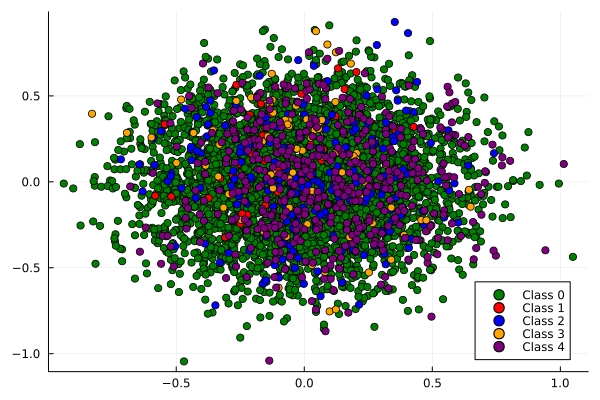

In [144]:
# one hot encoding only for graph
one_hot_train_output = oneHotEncoding(train_output)

colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_3, one_hot_train_output; colors=colors, target_names=target_names)

In [145]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
                                    (pca_train_3, train_output),
                                    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (1.0, 0.0)
  "positive_predictive_value" => (4.82745, 0.0124775)
  "specificity"               => (4.0, 0.0)
  "negative_predictive_value" => (4.82745, 0.0124775)
  "f_score"                   => (0.905541, 0.00746651)
  "accuracy"                  => (0.827454, 0.0124775)
  "error_rate"                => (0.172546, 0.0124775)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.827454)…

In [146]:
models_accuracies[!, :PCA_3] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_3] = m[3]
    i += 1
end

In [148]:
metrics_pca3 = [
    "PCA_3",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca3)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.949269,0.0507309,3.13948,4.77888,4.79351,4.88348,3.36328
2,ZeroMean,0.94583,0.0541702,2.99785,4.77525,4.61692,4.87996,3.19526
3,CrossVal,0.941053,0.0589472,2.522,4.76129,4.60325,4.91741,2.56083
4,PCA_3,0.827454,0.172546,1.0,4.0,4.82745,4.82745,0.905541


In [149]:
# Display results
println("METRICS 4th APPROACH (PCA 3 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 3 dimensions):
---------------------
Accuracy: 0.8274544255008855
Error Rate: 0.17254557449911453
Sensitivity (Recall): 1.0
Specificity: 4.0
Precision: 4.827454425500886
Negative Predictive Value: 4.8274544255008855
F-Score: 0.9055406790008396
----------------------



## Second apply a reduction conserving 95% of the representation

In [150]:
## Apply a reduction conserving the 95% of the representation of the data
pca_95 = PCA(0.95)
fit!(pca_95, train_input_minmax)

#Once it is ajusted it can be used to transform the data
pca_train_95 = pca_95.transform(train_input_minmax)
pca_test_95 = pca_95.transform(test_input_minmax)

print("Train Patterns ", size(train_input_minmax), " -> ", size(pca_train_95))
print("Train Patterns ", size(test_input_minmax), " -> ", size(pca_test_95))

Train Patterns (4648, 13) -> (4648, 11)Train Patterns (1163, 13) -> (1163, 11)

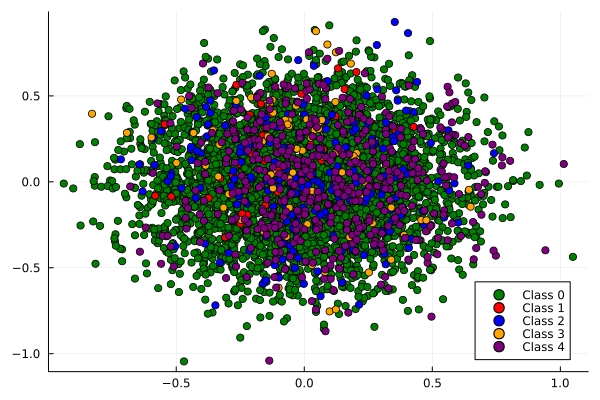

In [151]:
one_hot_train_output = oneHotEncoding(train_output)
colors = [:green, :red, :blue, :orange, :purple]
target_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]

# Call the function
draw_results(pca_train_95, one_hot_train_output; colors=colors, target_names=target_names)

In [152]:
metrics_given = trainClassEnsemble(modelsHyperParameters,
    (pca_train_95, train_output),
    kFoldIndices)

/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/pablo/Dropbox/MIA/ML1/sk/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

Dict{String, Any} with 8 entries:
  "sensitivity"               => (2.50662, 0.135061)
  "positive_predictive_value" => (4.54416, 0.101977)
  "specificity"               => (4.75213, 0.0699478)
  "negative_predictive_value" => (4.89539, 0.0161863)
  "f_score"                   => (2.51358, 0.092037)
  "accuracy"                  => (0.936104, 0.0103161)
  "error_rate"                => (0.0638955, 0.0103161)
  "models_accuracies"         => Tuple{Int64, Any, Float64}[(1, :ANN, 0.929002)…

In [153]:
models_accuracies[!, :PCA_095] .= 0.0
i = 1
for m in metrics_given["models_accuracies"]
    models_accuracies[i, :PCA_095] = m[3]
    i += 1
end

In [154]:
metrics_pca95 = [
    "PCA_095",
    metrics_given["accuracy"][1],
    metrics_given["error_rate"][1],
    metrics_given["sensitivity"][1],
    metrics_given["specificity"][1],
    metrics_given["positive_predictive_value"][1],
    metrics_given["negative_predictive_value"][1],
    metrics_given["f_score"][1]
]
push!(metrics, metrics_pca95)

Row,approach,accuracy,error_rate,recall,specificity,ppv,npv,f_score
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,MinMax,0.949269,0.0507309,3.13948,4.77888,4.79351,4.88348,3.36328
2,ZeroMean,0.94583,0.0541702,2.99785,4.77525,4.61692,4.87996,3.19526
3,CrossVal,0.941053,0.0589472,2.522,4.76129,4.60325,4.91741,2.56083
4,PCA_3,0.827454,0.172546,1.0,4.0,4.82745,4.82745,0.905541
5,PCA_095,0.936104,0.0638955,2.50662,4.75213,4.54416,4.89539,2.51358


In [155]:
# Display results
println("METRICS 4th APPROACH (PCA 0.95 dimensions):")
println("---------------------")
println("Accuracy: ", metrics_given["accuracy"][1])
println("Error Rate: ", metrics_given["error_rate"][1])
println("Sensitivity (Recall): ", metrics_given["sensitivity"][1])
println("Specificity: ", metrics_given["specificity"][1])
println("Precision: ", metrics_given["positive_predictive_value"][1])
println("Negative Predictive Value: ", metrics_given["negative_predictive_value"][1])
println("F-Score: ", metrics_given["f_score"][1])
println("----------------------")
println()

METRICS 4th APPROACH (PCA 0.95 dimensions):
---------------------
Accuracy: 0.9361044943690174
Error Rate: 0.06389550563098259
Sensitivity (Recall): 2.506619186160738
Specificity: 4.75212541104531
Precision: 4.544156025016477
Negative Predictive Value: 4.895387273679384
F-Score: 2.51357749999823
----------------------



# Results

In [160]:
println(metrics)

5×8 DataFrame
 Row │ approach  accuracy  error_rate  recall   specificity  ppv      npv      f_score  
     │ String    Float64   Float64     Float64  Float64      Float64  Float64  Float64  
─────┼──────────────────────────────────────────────────────────────────────────────────
   1 │ MinMax    0.949269   0.0507309  3.13948      4.77888  4.79351  4.88348  3.36328
   2 │ ZeroMean  0.94583    0.0541702  2.99785      4.77525  4.61692  4.87996  3.19526
   3 │ CrossVal  0.941053   0.0589472  2.522        4.76129  4.60325  4.91741  2.56083
   4 │ PCA_3     0.827454   0.172546   1.0          4.0      4.82745  4.82745  0.905541
   5 │ PCA_095   0.936104   0.0638955  2.50662      4.75213  4.54416  4.89539  2.51358


In [162]:
println(models_accuracies)

28×6 DataFrame
 Row │ Model           MinMax    ZeroMean  CrossVal  PCA_3     PCA_095  
     │ String          Float64   Float64   Float64   Float64   Float64  
─────┼──────────────────────────────────────────────────────────────────
   1 │ ANN_64          0.94669   0.94669   0.935027  0.827454  0.929002
   2 │ ANN_128         0.935512  0.932932  0.925342  0.827454  0.91975
   3 │ ANN_64_32       0.950989  0.951849  0.94062   0.827454  0.936534
   4 │ ANN_128_64      0.949269  0.940671  0.930724  0.82272   0.925346
   5 │ ANN_256         0.938951  0.940671  0.933521  0.826809  0.915879
   6 │ ANN_128_64_32   0.88908   0.948409  0.925563  0.814757  0.93008
   7 │ ANN_64_64       0.947549  0.949269  0.933306  0.827024  0.930079
   8 │ ANN_256_128     0.935512  0.925193  0.931797  0.827239  0.930295
   9 │ SVM_rbf_05      0.885641  0.885641  0.882748  0.827454  0.884686
  10 │ SVM_linear_1    0.895959  0.895959  0.905121  0.827454  0.904046
  11 │ SVM_poly_001    0.827171  0.827171  0.827

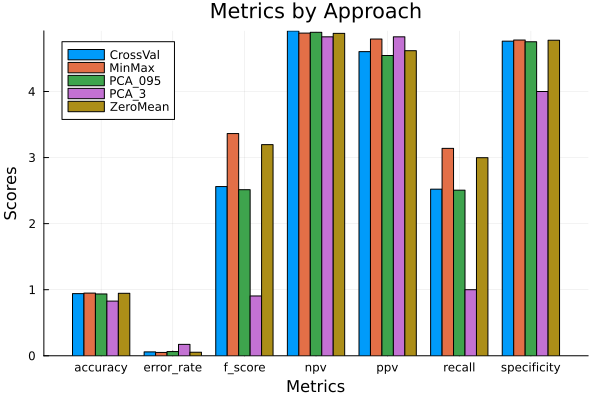

In [156]:
using StatsPlots

df = copy(metrics)

ctg = repeat(["MinMax", "ZeroMean", "CrossVal", "PCA_3", "PCA_095"], inner=7)
nam = repeat(names(df)[2:8], outer=5)
mm = collect(df[1,2:8])
zm = collect(df[2,2:8])
cv = collect(df[3,2:8])
pca3 = collect(df[4,2:8])
pca95 = collect(df[5,2:8])

groupedbar(nam, [mm zm cv pca3 pca95], group = ctg, xlabel = "Metrics", ylabel = "Scores",
           title = "Metrics by Approach")

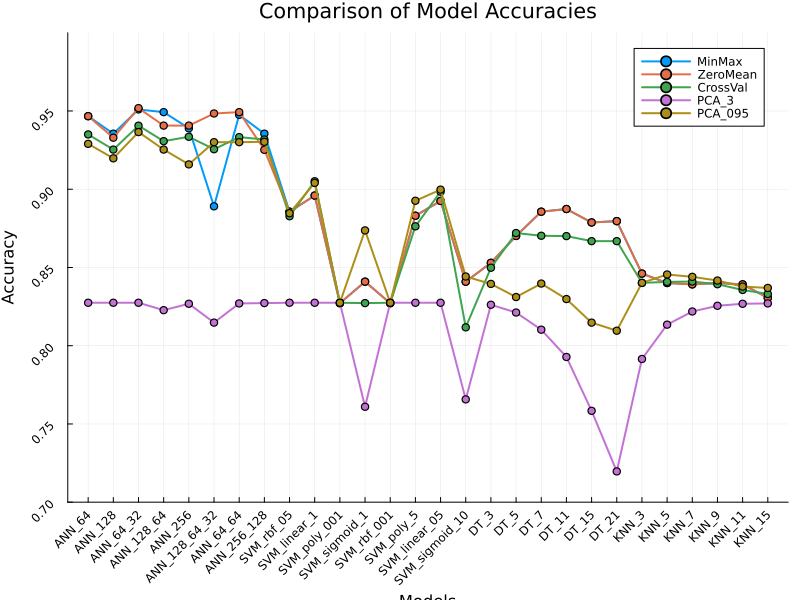

In [190]:
using Plots

df = copy(models_accuracies)

p = plot(
    1:nrow(df), 
    Matrix(df[:, 2:end]),
    label = permutedims(names(df)[2:end]),
    title = "Comparison of Model Accuracies",
    xlabel = "Models",
    ylabel = "Accuracy",
    legend = :topright,
    size = (800, 600),
    lw = 2,
    marker = :circle,
    markersize = 4
)
xticks!(1:nrow(df), df.Model, rotation = 45)
ylims!(0.7, 1.0)